# Generic Completeness Notebook

This notebook reads a generated Mendix plan JSON file and produces count-friendly tables for manual review:

- entities and their attributes
- associations
- pages and all nested page content
- microflows, nanoflows, and workflows
- flow actions and nested action details
- CSV exports for spreadsheet-based counting


In [12]:
from pathlib import Path
import json
from collections import Counter

import pandas as pd
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 250)
pd.set_option("display.width", 200)

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pipeline").exists() and (candidate / "evaluation").exists():
            return candidate
    raise RuntimeError("Could not locate replication package root.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
RUNS_ROOT = REPO_ROOT / "evaluation/runs/final_runs/20260606-091359/all_runs"

def plan_path(case: str, run: int) -> Path:
    return RUNS_ROOT / case / f"run-{run:02d}" / "plan.json"

# Run to be shown can be specified here
JSON_PATH = plan_path("brewery", 1)

assert JSON_PATH.exists(), f"File not found: {JSON_PATH.resolve()}"

with JSON_PATH.open("r", encoding="utf-8") as f:
    plan = json.load(f)

print(f"Loaded: {JSON_PATH}")
print("Top-level sections:", ", ".join(plan.keys()))

Loaded: /Users/matthiaslouws/Documents/Repositories/us2lc-pipeline-replication/evaluation/runs/final_runs/20260606-091359/all_runs/brewery/run-01/plan.json
Top-level sections: meta, app, execution, domainModel, security, pages, verification, microflows, nanoflows, workflows


## Helper functions

These functions normalize references, shorten long JSON values, and recursively flatten nested page and flow structures.

In [13]:
NESTED_CONTENT_KEYS = [
    "content",
    "itemContent",
    "templateContent",
    "children",
    "widgets",
    "actions",
    "steps",
    "branches",
    "items",
]

FLOW_SECTION_NAMES = ["microflows", "nanoflows", "workflows"]


def short_json(value, max_len=500):
    """Compact JSON/string rendering for table cells."""
    if value is None:
        return ""
    if isinstance(value, str):
        text = value
    else:
        try:
            text = json.dumps(value, ensure_ascii=False, sort_keys=True)
        except TypeError:
            text = str(value)
    if len(text) > max_len:
        return text[: max_len - 1] + "…"
    return text


def leaf_name(ref):
    """Return final part of a qualified reference, e.g. MyFirstModule.Task -> Task."""
    if not ref or not isinstance(ref, str):
        return ref
    return ref.split(".")[-1]


def count_types(rows, column):
    if not rows:
        return ""
    counts = Counter(row.get(column, "") for row in rows if row.get(column, ""))
    return ", ".join(f"{k}: {v}" for k, v in sorted(counts.items()))


def safe_list(value):
    return value if isinstance(value, list) else []


def extract_section_specs(data, section_name):
    """Support both {'specs': [...]} and direct list forms."""
    section = data.get(section_name, [])
    if isinstance(section, dict):
        specs = section.get("specs", [])
        return specs if isinstance(specs, list) else []
    if isinstance(section, list):
        return section
    return []


def walk_nested_dicts(value, path="root"):
    """Yield dict/list tree nodes with paths. Useful for inspecting unknown JSON shapes."""
    if isinstance(value, dict):
        yield path, value
        for k, v in value.items():
            yield from walk_nested_dicts(v, f"{path}.{k}")
    elif isinstance(value, list):
        for i, v in enumerate(value):
            yield from walk_nested_dicts(v, f"{path}[{i}]")

## 1. Entities, attributes, associations

In [14]:
def extract_entities(data):
    entities = data.get("domainModel", {}).get("entities", [])
    entity_rows = []
    attribute_rows = []

    for entity in entities:
        attrs = safe_list(entity.get("attributes"))
        entity_name = entity.get("name", "")
        entity_rows.append(
            {
                "entity": entity_name,
                "attribute_count": len(attrs),
                "required_attribute_count": sum(1 for a in attrs if a.get("required") is True),
                "attributes": ", ".join(a.get("name", "") for a in attrs),
                "raw_json": short_json(entity),
            }
        )
        for idx, attr in enumerate(attrs, start=1):
            attribute_rows.append(
                {
                    "entity": entity_name,
                    "attribute_index": idx,
                    "attribute": attr.get("name", ""),
                    "type": attr.get("type", ""),
                    "required": attr.get("required", ""),
                    "defaultValue": attr.get("defaultValue", ""),
                    "raw_json": short_json(attr),
                }
            )

    return pd.DataFrame(entity_rows), pd.DataFrame(attribute_rows)


def extract_associations(data):
    associations = data.get("domainModel", {}).get("associations", [])
    rows = []
    for idx, assoc in enumerate(associations, start=1):
        rows.append(
            {
                "association_index": idx,
                "association": assoc.get("name", ""),
                "parentEntity": assoc.get("parentEntity", ""),
                "childEntity": assoc.get("childEntity", ""),
                "type": assoc.get("type", ""),
                "owner": assoc.get("owner", ""),
                "raw_json": short_json(assoc),
            }
        )
    return pd.DataFrame(rows)

entity_summary_df, entity_attributes_df = extract_entities(plan)
associations_df = extract_associations(plan)

display(Markdown("### Entity summary"))
display(entity_summary_df)

display(Markdown("### Entity attributes"))
display(entity_attributes_df)

display(Markdown("### Associations"))
display(associations_df)

### Entity summary

,entity,attribute_count,required_attribute_count,attributes,raw_json
0,Brewery,3,0,"Name, Address, AccountStatus","{""attributes"": [{""name"": ""Name"", ""required"": false, ""type"": ""String""}, {""name"": ""Address"", ""required"": false, ""type"": ""String""}, {""name"": ""AccountStatus"", ""required"": false, ""type"": ""String""}], ""name"": ""Brewery""}"
1,HospitalityBusiness,2,0,"Name, Address","{""attributes"": [{""name"": ""Name"", ""required"": false, ""type"": ""String""}, {""name"": ""Address"", ""required"": false, ""type"": ""String""}], ""name"": ""HospitalityBusiness""}"
2,Beer,1,0,Name,"{""attributes"": [{""name"": ""Name"", ""required"": false, ""type"": ""String""}], ""name"": ""Beer""}"
3,Product,3,0,"Name, Description, Price","{""attributes"": [{""name"": ""Name"", ""required"": false, ""type"": ""String""}, {""name"": ""Description"", ""required"": false, ""type"": ""String""}, {""name"": ""Price"", ""required"": false, ""type"": ""Decimal""}], ""name"": ""Product""}"
4,Order,4,0,"Date, Total, Status, CancellationStatus","{""attributes"": [{""name"": ""Date"", ""required"": false, ""type"": ""DateTime""}, {""name"": ""Total"", ""required"": false, ""type"": ""Decimal""}, {""name"": ""Status"", ""required"": false, ""type"": ""String""}, {""name"": ""CancellationStatus"", ""required"": false, ""type"": ""..."
5,OrderTemplate,3,0,"Name, Description, ReorderFunctionality","{""attributes"": [{""name"": ""Name"", ""required"": false, ""type"": ""String""}, {""name"": ""Description"", ""required"": false, ""type"": ""String""}, {""name"": ""ReorderFunctionality"", ""required"": false, ""type"": ""Boolean""}], ""name"": ""OrderTemplate""}"
6,Contract,3,0,"StartDate, EndDate, ExpirationDate","{""attributes"": [{""name"": ""StartDate"", ""required"": false, ""type"": ""DateTime""}, {""name"": ""EndDate"", ""required"": false, ""type"": ""DateTime""}, {""name"": ""ExpirationDate"", ""required"": false, ""type"": ""DateTime""}], ""name"": ""Contract""}"
7,Proposal,2,0,"Date, Description","{""attributes"": [{""name"": ""Date"", ""required"": false, ""type"": ""DateTime""}, {""name"": ""Description"", ""required"": false, ""type"": ""String""}], ""name"": ""Proposal""}"
8,AppUser,3,1,"Name, Email, IsActive","{""attributes"": [{""name"": ""Name"", ""required"": true, ""type"": ""String""}, {""name"": ""Email"", ""required"": false, ""type"": ""String""}, {""defaultValue"": false, ""name"": ""IsActive"", ""required"": false, ""type"": ""Boolean""}], ""name"": ""AppUser""}"
9,Beer2beerManagementUser,7,2,"Name, Email, IsActive, PerformanceMetrics, Title, Description, Status","{""attributes"": [{""name"": ""Name"", ""required"": true, ""type"": ""String""}, {""name"": ""Email"", ""required"": false, ""type"": ""String""}, {""defaultValue"": false, ""name"": ""IsActive"", ""required"": false, ""type"": ""Boolean""}, {""name"": ""PerformanceMetrics"", ""requi..."


### Entity attributes

,entity,attribute_index,attribute,type,required,defaultValue,raw_json
0,Brewery,1,Name,String,False,,"{""name"": ""Name"", ""required"": false, ""type"": ""String""}"
1,Brewery,2,Address,String,False,,"{""name"": ""Address"", ""required"": false, ""type"": ""String""}"
2,Brewery,3,AccountStatus,String,False,,"{""name"": ""AccountStatus"", ""required"": false, ""type"": ""String""}"
3,HospitalityBusiness,1,Name,String,False,,"{""name"": ""Name"", ""required"": false, ""type"": ""String""}"
4,HospitalityBusiness,2,Address,String,False,,"{""name"": ""Address"", ""required"": false, ""type"": ""String""}"
5,Beer,1,Name,String,False,,"{""name"": ""Name"", ""required"": false, ""type"": ""String""}"
6,Product,1,Name,String,False,,"{""name"": ""Name"", ""required"": false, ""type"": ""String""}"
7,Product,2,Description,String,False,,"{""name"": ""Description"", ""required"": false, ""type"": ""String""}"
8,Product,3,Price,Decimal,False,,"{""name"": ""Price"", ""required"": false, ""type"": ""Decimal""}"
9,Order,1,Date,DateTime,False,,"{""name"": ""Date"", ""required"": false, ""type"": ""DateTime""}"


### Associations

,association_index,association,parentEntity,childEntity,type,owner,raw_json
0,1,BreweryHasProduct,Brewery,Product,Reference,Both,"{""childEntity"": ""Product"", ""name"": ""BreweryHasProduct"", ""owner"": ""Both"", ""parentEntity"": ""Brewery"", ""type"": ""Reference""}"
1,2,HospitalityBusinessPlacesOrder,HospitalityBusiness,Order,Reference,Both,"{""childEntity"": ""Order"", ""name"": ""HospitalityBusinessPlacesOrder"", ""owner"": ""Both"", ""parentEntity"": ""HospitalityBusiness"", ""type"": ""Reference""}"
2,3,BreweryHasContract,Brewery,Contract,Reference,Both,"{""childEntity"": ""Contract"", ""name"": ""BreweryHasContract"", ""owner"": ""Both"", ""parentEntity"": ""Brewery"", ""type"": ""Reference""}"
3,4,OrderHasOrderTemplate,Order,OrderTemplate,Reference,Both,"{""childEntity"": ""OrderTemplate"", ""name"": ""OrderHasOrderTemplate"", ""owner"": ""Both"", ""parentEntity"": ""Order"", ""type"": ""Reference""}"
4,5,HospitalityBusinessHasShoppingCart,HospitalityBusiness,ShoppingCart,Reference,Both,"{""childEntity"": ""ShoppingCart"", ""name"": ""HospitalityBusinessHasShoppingCart"", ""owner"": ""Both"", ""parentEntity"": ""HospitalityBusiness"", ""type"": ""Reference""}"
5,6,Beer2beerManagementUserManagesLogicOperation,Beer2beerManagementUser,LogicOperation,Reference,Both,"{""childEntity"": ""LogicOperation"", ""name"": ""Beer2beerManagementUserManagesLogicOperation"", ""owner"": ""Both"", ""parentEntity"": ""Beer2beerManagementUser"", ""type"": ""Reference""}"
6,7,BreweryHasAccount,Brewery,AppUser,Reference,Both,"{""childEntity"": ""AppUser"", ""name"": ""BreweryHasAccount"", ""owner"": ""Both"", ""parentEntity"": ""Brewery"", ""type"": ""Reference""}"
7,8,HospitalityBusinessHasOrderCommission,HospitalityBusiness,OrderCommission,Reference,Both,"{""childEntity"": ""OrderCommission"", ""name"": ""HospitalityBusinessHasOrderCommission"", ""owner"": ""Both"", ""parentEntity"": ""HospitalityBusiness"", ""type"": ""Reference""}"
8,9,BreweryHasDeliveryCapacity,Brewery,DeliveryCapacity,Reference,Both,"{""childEntity"": ""DeliveryCapacity"", ""name"": ""BreweryHasDeliveryCapacity"", ""owner"": ""Both"", ""parentEntity"": ""Brewery"", ""type"": ""Reference""}"
9,10,HospitalityBusinessHasRecurringOrderSchedule,HospitalityBusiness,RecurringOrderSchedule,Reference,Both,"{""childEntity"": ""RecurringOrderSchedule"", ""name"": ""HospitalityBusinessHasRecurringOrderSchedule"", ""owner"": ""Both"", ""parentEntity"": ""HospitalityBusiness"", ""type"": ""Reference""}"


## 2. Pages and nested page content

In [15]:
def flatten_page_content(page):
    rows = []
    page_ref = page.get("ref", "")
    page_name = page.get("name", "")
    page_title = page.get("title", "")
    page_entity_ref = page.get("entityRef", "")
    page_parameters = page.get("pageParameters", [])

    def add_nodes(nodes, parent_path="content", parent_section="content", depth=0):
        if not isinstance(nodes, list):
            return
        for idx, node in enumerate(nodes):
            path = f"{parent_path}[{idx}]"
            if not isinstance(node, dict):
                rows.append(
                    {
                        "page_ref": page_ref,
                        "page_name": page_name,
                        "page_title": page_title,
                        "page_entityRef": page_entity_ref,
                        "page_entity": leaf_name(page_entity_ref),
                        "layoutQualifiedName": page.get("layoutQualifiedName", ""),
                        "page_parameters": short_json(page_parameters),
                        "depth": depth,
                        "parent_section": parent_section,
                        "path": path,
                        "widget_type": type(node).__name__,
                        "text": short_json(node),
                        "caption": "",
                        "renderMode": "",
                        "entityRef": "",
                        "entity": "",
                        "attributeRef": "",
                        "associationRef": "",
                        "targetEntityRef": "",
                        "targetEntity": "",
                        "targetPageRef": "",
                        "rowClickTargetPageRef": "",
                        "pageParameterName": "",
                        "label": "",
                        "autoLabel": "",
                        "raw_json": short_json(node),
                    }
                )
                continue

            row = {
                "page_ref": page_ref,
                "page_name": page_name,
                "page_title": page_title,
                "page_entityRef": page_entity_ref,
                "page_entity": leaf_name(page_entity_ref),
                "layoutQualifiedName": page.get("layoutQualifiedName", ""),
                "page_parameters": short_json(page_parameters),
                "depth": depth,
                "parent_section": parent_section,
                "path": path,
                "widget_type": node.get("type", ""),
                "text": node.get("text", ""),
                "caption": node.get("caption", ""),
                "renderMode": node.get("renderMode", ""),
                "entityRef": node.get("entityRef", ""),
                "entity": leaf_name(node.get("entityRef", "")),
                "attributeRef": node.get("attributeRef", ""),
                "associationRef": node.get("associationRef", ""),
                "targetEntityRef": node.get("targetEntityRef", ""),
                "targetEntity": leaf_name(node.get("targetEntityRef", "")),
                "targetPageRef": node.get("targetPageRef", ""),
                "rowClickTargetPageRef": node.get("rowClickTargetPageRef", ""),
                "pageParameterName": node.get("pageParameterName", ""),
                "label": node.get("label", ""),
                "autoLabel": node.get("autoLabel", ""),
                "raw_json": short_json(node),
            }
            rows.append(row)

            for nested_key in NESTED_CONTENT_KEYS:
                nested_value = node.get(nested_key)
                if isinstance(nested_value, list):
                    add_nodes(
                        nested_value,
                        parent_path=f"{path}.{nested_key}",
                        parent_section=nested_key,
                        depth=depth + 1,
                    )

    add_nodes(page.get("content", []), parent_path="content", parent_section="content", depth=0)
    return rows


def extract_pages(data):
    pages = extract_section_specs(data, "pages")
    content_rows = []
    summary_rows = []

    for page in pages:
        rows = flatten_page_content(page)
        content_rows.extend(rows)
        widget_types = Counter(row.get("widget_type", "") for row in rows if row.get("widget_type", ""))
        target_pages = sorted(
            set(
                value
                for row in rows
                for value in [row.get("targetPageRef", ""), row.get("rowClickTargetPageRef", "")]
                if value
            )
        )
        summary_rows.append(
            {
                "page_ref": page.get("ref", ""),
                "page_name": page.get("name", ""),
                "page_title": page.get("title", ""),
                "entityRef": page.get("entityRef", ""),
                "entity": leaf_name(page.get("entityRef", "")),
                "layoutQualifiedName": page.get("layoutQualifiedName", ""),
                "page_parameter_count": len(safe_list(page.get("pageParameters"))),
                "content_item_count_recursive": len(rows),
                "attributeInput_count": widget_types.get("attributeInput", 0),
                "associationInput_count": widget_types.get("associationInput", 0),
                "listView_count": widget_types.get("listView", 0),
                "dataView_count": widget_types.get("dataView", 0),
                "button_count": sum(v for k, v in widget_types.items() if "button" in str(k).lower()),
                "dynamicText_count": widget_types.get("dynamicText", 0),
                "target_pages": ", ".join(target_pages),
                "widget_type_breakdown": ", ".join(f"{k}: {v}" for k, v in sorted(widget_types.items())),
                "raw_json": short_json(page),
            }
        )

    return pd.DataFrame(summary_rows), pd.DataFrame(content_rows)

page_summary_df, page_content_df = extract_pages(plan)

display(Markdown("### Page summary"))
display(page_summary_df)

display(Markdown("### All nested page content"))
display(page_content_df)

### Page summary

,page_ref,page_name,page_title,entityRef,entity,layoutQualifiedName,page_parameter_count,content_item_count_recursive,attributeInput_count,associationInput_count,listView_count,dataView_count,button_count,dynamicText_count,target_pages,widget_type_breakdown,raw_json
0,home,Home,Home,,,,0,11,0,0,0,0,9,2,"appuser_overview, beer2beermanagementuser_overview, beer_overview, brewery_overview, breweryorhospitalitybusiness_overview, contract_overview, order_dashboard, order_overview, product_overview","buttonToPage: 9, dynamicText: 2","{""content"": [{""renderMode"": ""H2"", ""text"": ""Order Workspace"", ""type"": ""dynamicText""}, {""renderMode"": ""Paragraph"", ""text"": ""Generated from user stories"", ""type"": ""dynamicText""}, {""caption"": ""Order Dashboard"", ""targetPageRef"": ""order_dashboard"", ""ty..."
1,order_dashboard,Order_Dashboard,Order Dashboard,MyFirstModule.Order,Order,,0,5,1,0,1,0,1,2,order_newedit,"attributeInput: 1, createObjectButton: 1, dynamicText: 2, listView: 1","{""content"": [{""renderMode"": ""H2"", ""text"": ""Order Dashboard"", ""type"": ""dynamicText""}, {""renderMode"": ""Paragraph"", ""text"": ""Overview and data management for order."", ""type"": ""dynamicText""}, {""caption"": ""Add Order"", ""entityRef"": ""MyFirstModule.Order..."
2,order_overview,Order_Overview,Order Overview,MyFirstModule.Order,Order,,0,5,1,0,1,0,1,2,order_newedit,"attributeInput: 1, createObjectButton: 1, dynamicText: 2, listView: 1","{""content"": [{""renderMode"": ""H2"", ""text"": ""Order Overview"", ""type"": ""dynamicText""}, {""renderMode"": ""Paragraph"", ""text"": ""Manage order records and open the create dialog when new data is needed."", ""type"": ""dynamicText""}, {""caption"": ""Add Order"", ""..."
3,order_newedit,Order_NewEdit,Order NewEdit,MyFirstModule.Order,Order,Atlas_Core.PopupLayout,1,9,4,2,0,1,2,0,,"associationInput: 2, attributeInput: 4, cancelChangesButton: 1, dataView: 1, saveChangesButton: 1","{""content"": [{""content"": [{""attributeRef"": ""Date"", ""type"": ""attributeInput""}, {""attributeRef"": ""Total"", ""type"": ""attributeInput""}, {""attributeRef"": ""Status"", ""type"": ""attributeInput""}, {""attributeRef"": ""CancellationStatus"", ""type"": ""attributeInpu..."
4,beer_overview,Beer_Overview,Beer Overview,MyFirstModule.Beer,Beer,,0,5,1,0,1,0,1,2,beer_newedit,"attributeInput: 1, createObjectButton: 1, dynamicText: 2, listView: 1","{""content"": [{""renderMode"": ""H2"", ""text"": ""Beer Overview"", ""type"": ""dynamicText""}, {""renderMode"": ""Paragraph"", ""text"": ""Manage beer records and open the create dialog when new data is needed."", ""type"": ""dynamicText""}, {""caption"": ""Add Beer"", ""ent..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,breweryuser_newedit,BreweryUser_NewEdit,BreweryUser NewEdit,MyFirstModule.BreweryUser,BreweryUser,Atlas_Core.PopupLayout,1,6,3,0,0,1,2,0,,"attributeInput: 3, cancelChangesButton: 1, dataView: 1, saveChangesButton: 1","{""content"": [{""content"": [{""attributeRef"": ""Name"", ""type"": ""attributeInput""}, {""attributeRef"": ""Email"", ""type"": ""attributeInput""}, {""attributeRef"": ""IsActive"", ""type"": ""attributeInput""}, {""caption"": ""Save"", ""closePage"": true, ""type"": ""saveChanges..."
69,hospitalitybusinessuser_overview,HospitalityBusinessUser_Overview,HospitalityBusinessUser Overview,MyFirstModule.HospitalityBusinessUser,HospitalityBusinessUser,,0,6,3,0,1,0,1,1,hospitalitybusinessuser_newedit,"attributeInput: 3, createObjectButton: 1, dynamicText: 1, listView: 1","{""content"": [{""renderMode"": ""H2"", ""text"": ""HospitalityBusinessUser Overview"", ""type"": ""dynamicText""}, {""caption"": ""Create HospitalityBusinessUser"", ""entityRef"": ""MyFirstModule.HospitalityBusinessUser"", ""targetPageRef"": ""hospitalitybusinessuser_ne..."
70,hospitalitybusinessuser_newedit,HospitalityBusinessUser_NewEdit,HospitalityBusinessUser NewEdit,MyFirstModule.HospitalityBusinessUser,HospitalityBusinessUser,Atl

### All nested page content

,page_ref,page_name,page_title,page_entityRef,page_entity,layoutQualifiedName,page_parameters,depth,parent_section,path,widget_type,text,caption,renderMode,entityRef,entity,attributeRef,associationRef,targetEntityRef,targetEntity,targetPageRef,rowClickTargetPageRef,pageParameterName,label,autoLabel,raw_json
0,home,Home,Home,,,,[],0,content,content[0],dynamicText,Order Workspace,,H2,,,,,,,,,,,,"{""renderMode"": ""H2"", ""text"": ""Order Workspace"", ""type"": ""dynamicText""}"
1,home,Home,Home,,,,[],0,content,content[1],dynamicText,Generated from user stories,,Paragraph,,,,,,,,,,,,"{""renderMode"": ""Paragraph"", ""text"": ""Generated from user stories"", ""type"": ""dynamicText""}"
2,home,Home,Home,,,,[],0,content,content[2],buttonToPage,,Order Dashboard,,,,,,,,order_dashboard,,,,,"{""caption"": ""Order Dashboard"", ""targetPageRef"": ""order_dashboard"", ""type"": ""buttonToPage""}"
3,home,Home,Home,,,,[],0,content,content[3],buttonToPage,,Order Overview,,,,,,,,order_overview,,,,,"{""caption"": ""Order Overview"", ""targetPageRef"": ""order_overview"", ""type"": ""buttonToPage""}"
4,home,Home,Home,,,,[],0,content,content[4],buttonToPage,,Beer Overview,,,,,,,,beer_overview,,,,,"{""caption"": ""Beer Overview"", ""targetPageRef"": ""beer_overview"", ""type"": ""buttonToPage""}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,appadministrator_newedit,AppAdministrator_NewEdit,AppAdministrator NewEdit,MyFirstModule.AppAdministrator,AppAdministrator,Atlas_Core.PopupLayout,"[{""entityRef"": ""MyFirstModule.AppAdministrator"", ""name"": ""AppAdministrator"", ""required"": true}]",1,content,content[0].content[0],attributeInput,,,,,,Name,,,,,,,,,"{""attributeRef"": ""Name"", ""type"": ""attributeInput""}"
305,appadministrator_newedit,AppAdministrator_NewEdit,AppAdministrator NewEdit,MyFirstModule.AppAdministrator,AppAdministrator,Atlas_Core.PopupLayout,"[{""entityRef"": ""MyFirstModule.AppAdministrator"", ""name"": ""AppAdministrator"", ""required"": true}]",1,content,content[0].content[1],attributeInput,,,,,,Email,,,,,,,,,"{""attributeRef"": ""Email"", ""type"": ""attributeInput""}"
306,appadministrator_newedit,AppAdministrator_NewEdit,AppAdministrator NewEdit,MyFirstModule.AppAdministrator,AppAdministrator,Atlas_Core.PopupLayout,"[{""entityRef"": ""MyFirstModule.AppAdministrator"", ""name"": ""AppAdministrator"", ""required"": true}]",1,content,content[0].content[2],attributeInput,,,,,,IsActive,,,,,,,,,"{""attributeRef"": ""IsActive"", ""type"": ""attributeInput""}"
307,appadministrator_newedit,AppAdministrator_NewEdit,AppAdministrator NewEdit,MyFirstModule.AppAdministrator,AppAdministrator,Atlas_Core.PopupLayout,"[{""entityRef"": ""MyFirstModule.AppAdministrator"", ""name"": ""AppAdministrator"", ""required"": true}]",1,content,content[0].content[3],saveChangesButton,,Save,,,,,,,,,,,,,"{""caption"": ""Save"", ""closePage"": true, ""type"": ""saveChangesButton""}"


### Count of pages with less than 2 items:

In [16]:
low_content_pages_df = page_summary_df[
    page_summary_df["content_item_count_recursive"] < 2
]

count_low_content_pages = len(low_content_pages_df)

display(Markdown(f"### Pages with fewer than 2 recursive content items: {count_low_content_pages}"))
display(low_content_pages_df)

### Pages with fewer than 2 recursive content items: 24

,page_ref,page_name,page_title,entityRef,entity,layoutQualifiedName,page_parameter_count,content_item_count_recursive,attributeInput_count,associationInput_count,listView_count,dataView_count,button_count,dynamicText_count,target_pages,widget_type_breakdown,raw_json
21,breweryoverview,BreweryOverview,Brewery Overview,MyFirstModule.Brewery,Brewery,,0,1,0,0,0,0,0,1,,dynamicText: 1,"{""content"": [{""renderMode"": ""H2"", ""text"": ""Brewery Overview"", ""type"": ""dynamicText""}], ""entityRef"": ""MyFirstModule.Brewery"", ""name"": ""BreweryOverview"", ""ref"": ""breweryoverview"", ""title"": ""Brewery Overview""}"
22,brewerydetail,BreweryDetail,Brewery Detail,MyFirstModule.Brewery,Brewery,,0,1,0,0,0,0,0,1,,dynamicText: 1,"{""content"": [{""renderMode"": ""H2"", ""text"": ""Brewery Detail"", ""type"": ""dynamicText""}], ""entityRef"": ""MyFirstModule.Brewery"", ""name"": ""BreweryDetail"", ""ref"": ""brewerydetail"", ""title"": ""Brewery Detail""}"
23,brewerynewedit,BreweryNewEdit,Brewery New Edit,MyFirstModule.Brewery,Brewery,,0,1,0,0,0,0,0,1,,dynamicText: 1,"{""content"": [{""renderMode"": ""H2"", ""text"": ""Brewery New Edit"", ""type"": ""dynamicText""}], ""entityRef"": ""MyFirstModule.Brewery"", ""name"": ""BreweryNewEdit"", ""ref"": ""brewerynewedit"", ""title"": ""Brewery New Edit""}"
24,hospitalitybusinessoverview,HospitalityBusinessOverview,Hospitality Business Overview,MyFirstModule.HospitalityBusiness,HospitalityBusiness,,0,1,0,0,0,0,0,1,,dynamicText: 1,"{""content"": [{""renderMode"": ""H2"", ""text"": ""Hospitality Business Overview"", ""type"": ""dynamicText""}], ""entityRef"": ""MyFirstModule.HospitalityBusiness"", ""name"": ""HospitalityBusinessOverview"", ""ref"": ""hospitalitybusinessoverview"", ""title"": ""Hospitali..."
25,hospitalitybusinessdetail,HospitalityBusinessDetail,Hospitality Business Detail,MyFirstModule.HospitalityBusiness,HospitalityBusiness,,0,1,0,0,0,0,0,1,,dynamicText: 1,"{""content"": [{""renderMode"": ""H2"", ""text"": ""Hospitality Business Detail"", ""type"": ""dynamicText""}], ""entityRef"": ""MyFirstModule.HospitalityBusiness"", ""name"": ""HospitalityBusinessDetail"", ""ref"": ""hospitalitybusinessdetail"", ""title"": ""Hospitality Bus..."
26,hospitalitybusinessnewedit,HospitalityBusinessNewEdit,Hospitality Business New Edit,MyFirstModule.HospitalityBusiness,HospitalityBusiness,,0,1,0,0,0,0,0,1,,dynamicText: 1,"{""content"": [{""renderMode"": ""H2"", ""text"": ""Hospitality Business New Edit"", ""type"": ""dynamicText""}], ""entityRef"": ""MyFirstModule.HospitalityBusiness"", ""name"": ""HospitalityBusinessNewEdit"", ""ref"": ""hospitalitybusinessnewedit"", ""title"": ""Hospitality..."
27,beeroverview,BeerOverview,Beer Overview,MyFirstModule.Beer,Beer,,0,1,0,0,0,0,0,1,,dynamicText: 1,"{""content"": [{""renderMode"": ""H2"", ""text"": ""Beer Overview"", ""type"": ""dynamicText""}], ""entityRef"": ""MyFirstModule.Beer"", ""name"": ""BeerOverview"", ""ref"": ""beeroverview"", ""title"": ""Beer Overview""}"
28,beerdetail,BeerDetail,Beer Detail,MyFirstModule.Beer,Beer,,0,1,0,0,0,0,0,1,,dynamicText: 1,"{""content"": [{""renderMode"": ""H2"", ""text"": ""Beer Detail"", ""type"": ""dynamicText""}], ""entityRef"": ""MyFirstModule.Beer"", ""name"": ""BeerDetail"", ""ref"": ""beerdetail"", ""title"": ""Beer Detail""}"
29,beernewedit,BeerNewEdit,Beer New Edit,MyFirstModule.Beer,Beer,,0,1,0,0,0,0,0,1,,dynamicText: 1,"{""content"": [{""renderMode"": ""H2"", ""text"": ""Beer New Edit"", ""type"": ""dynamicText""}], ""entityRef"": ""MyFirstModule.Beer"", ""name"": ""BeerNewEdit"", ""ref"": ""beernewedit"", ""title"": ""Beer New Edit""}"
30,productoverview,ProductOverview,Product Overview,MyFirstModule.Product,Product,,0,1,0,0,0,0,0,1,,dynamicText: 1,"{""content"": [{""renderMode"": ""H2"", ""text"": ""Product Overview"", ""type"": ""dynamicText""}], ""entityRef"": ""MyFirstModule.Product"", ""name"": ""ProductOverview"", ""ref"": ""productoverview"", ""title"": ""Product Overview""}"


## 3. Microflows, nanoflows, workflows


In [17]:
def flatten_action_nested_items(action, base_row, action_path):
    """Return nested detail rows below a flow action, excluding the action node itself."""
    rows = []
    for path, node in walk_nested_dicts(action, action_path):
        if path == action_path:
            continue
        if isinstance(node, dict):
            simple = {
                k: v
                for k, v in node.items()
                if not isinstance(v, (dict, list))
            }
            rows.append(
                {
                    **base_row,
                    "nested_path": path,
                    "nested_type": node.get("type", ""),
                    "attribute": node.get("attribute", node.get("attributeRef", "")),
                    "association": node.get("association", node.get("associationRef", "")),
                    "entity": node.get("entity", leaf_name(node.get("entityRef", ""))),
                    "variable": node.get("variableName", node.get("targetVariableName", node.get("outputVariableName", ""))),
                    "value": short_json(node.get("value", "")),
                    "operator": node.get("operator", ""),
                    "simple_fields": short_json(simple),
                    "raw_json": short_json(node),
                }
            )
    return rows


def extract_flows(data):
    flow_summary_rows = []
    flow_parameter_rows = []
    flow_action_rows = []
    flow_nested_rows = []

    for flow_type in FLOW_SECTION_NAMES:
        for flow_index, flow in enumerate(extract_section_specs(data, flow_type), start=1):
            flow_name = flow.get("name", "")
            parameters = safe_list(flow.get("parameters"))
            actions = safe_list(flow.get("actions"))

            action_types = [a.get("type", "") for a in actions if isinstance(a, dict)]
            touched_entities = sorted(
                set(
                    leaf_name(a.get("entity", a.get("entityRef", a.get("targetEntityRef", ""))))
                    for a in actions
                    if isinstance(a, dict) and (a.get("entity") or a.get("entityRef") or a.get("targetEntityRef"))
                )
            )

            flow_summary_rows.append(
                {
                    "flow_type": flow_type[:-1] if flow_type.endswith("s") else flow_type,
                    "flow_name": flow_name,
                    "flow_index": flow_index,
                    "parameter_count": len(parameters),
                    "action_count": len(actions),
                    "action_type_breakdown": ", ".join(f"{k}: {v}" for k, v in sorted(Counter(action_types).items())),
                    "entities_touched": ", ".join(touched_entities),
                    "raw_json": short_json(flow),
                }
            )

            for param_index, param in enumerate(parameters, start=1):
                flow_parameter_rows.append(
                    {
                        "flow_type": flow_type[:-1] if flow_type.endswith("s") else flow_type,
                        "flow_name": flow_name,
                        "parameter_index": param_index,
                        "parameter": param.get("name", "") if isinstance(param, dict) else short_json(param),
                        "type": param.get("type", "") if isinstance(param, dict) else "",
                        "raw_json": short_json(param),
                    }
                )

            for action_index, action in enumerate(actions, start=1):
                if not isinstance(action, dict):
                    base_row = {
                        "flow_type": flow_type[:-1] if flow_type.endswith("s") else flow_type,
                        "flow_name": flow_name,
                        "action_index": action_index,
                        "action_path": f"actions[{action_index - 1}]",
                    }
                    flow_action_rows.append(
                        {
                            **base_row,
                            "action_type": type(action).__name__,
                            "entity": "",
                            "variableName": "",
                            "targetVariableName": "",
                            "outputVariableName": "",
                            "value": short_json(action),
                            "changes_count": "",
                            "constraints_count": "",
                            "nested_item_count": "",
                            "raw_json": short_json(action),
                        }
                    )
                    continue

                base_row = {
                    "flow_type": flow_type[:-1] if flow_type.endswith("s") else flow_type,
                    "flow_name": flow_name,
                    "action_index": action_index,
                    "action_path": f"actions[{action_index - 1}]",
                }
                nested_items = flatten_action_nested_items(action, base_row, base_row["action_path"])
                flow_nested_rows.extend(nested_items)

                flow_action_rows.append(
                    {
                        **base_row,
                        "action_type": action.get("type", ""),
                        "entity": leaf_name(action.get("entity", action.get("entityRef", action.get("targetEntityRef", "")))),
                        "variableName": action.get("variableName", ""),
                        "targetVariableName": action.get("targetVariableName", ""),
                        "outputVariableName": action.get("outputVariableName", ""),
                        "value": short_json(action.get("value", "")),
                        "changes_count": len(safe_list(action.get("changes"))),
                        "constraints_count": len(safe_list(action.get("constraints"))),
                        "nested_item_count": len(nested_items),
                        "raw_json": short_json(action),
                    }
                )

    return (
        pd.DataFrame(flow_summary_rows),
        pd.DataFrame(flow_parameter_rows),
        pd.DataFrame(flow_action_rows),
        pd.DataFrame(flow_nested_rows),
    )

flow_summary_df, flow_parameters_df, flow_actions_df, flow_nested_details_df = extract_flows(plan)

display(Markdown("### Flow summary"))
display(flow_summary_df)

display(Markdown("### Flow parameters"))
display(flow_parameters_df)

display(Markdown("### Flow actions"))
display(flow_actions_df)

display(Markdown("### Nested action details"))
display(flow_nested_details_df)

### Flow summary

,flow_type,flow_name,flow_index,parameter_count,action_count,action_type_breakdown,entities_touched,raw_json
0,microflow,CreateProposalForBreweryRequest,1,2,2,"changeObject: 1, createObject: 1",Proposal,"{""actions"": [{""entity"": ""Proposal"", ""outputVariableName"": ""Proposal_New"", ""type"": ""createObject""}, {""changes"": [{""attributeRef"": ""Description"", ""valueExpression"": ""$proposalDescription""}], ""targetVariableName"": ""Proposal_New"", ""type"": ""changeObje..."
1,microflow,ApproveBrewerySignUpRequest,2,1,1,showMessage: 1,,"{""actions"": [{""message"": ""Brewery sign-up request approved successfully."", ""type"": ""showMessage""}], ""name"": ""ApproveBrewerySignUpRequest"", ""parameters"": [{""name"": ""breweryId"", ""type"": ""Integer""}]}"
2,microflow,CreateContractForProposal,3,1,1,createObject: 1,Contract,"{""actions"": [{""entity"": ""Contract"", ""outputVariableName"": ""Contract_New"", ""type"": ""createObject""}], ""name"": ""CreateContractForProposal"", ""parameters"": [{""name"": ""proposalId"", ""type"": ""Integer""}]}"
3,microflow,MF_Beer2beerManagementUser_Prepare,4,1,1,changeObject: 1,,"{""actions"": [{""changes"": [{""attributeRef"": ""Status"", ""valueExpression"": ""'In review'""}], ""commit"": ""yes"", ""targetVariableName"": ""WorkflowContext"", ""type"": ""changeObject""}], ""name"": ""MF_Beer2beerManagementUser_Prepare"", ""parameters"": [{""name"": ""Wo..."
4,microflow,MF_Beer2beerManagementUser_Approve,5,1,1,changeObject: 1,,"{""actions"": [{""changes"": [{""attributeRef"": ""Status"", ""valueExpression"": ""'Approved'""}], ""commit"": ""yes"", ""targetVariableName"": ""WorkflowContext"", ""type"": ""changeObject""}], ""name"": ""MF_Beer2beerManagementUser_Approve"", ""parameters"": [{""name"": ""Wor..."
5,microflow,MF_Beer2beerManagementUser_Reject,6,1,1,changeObject: 1,,"{""actions"": [{""changes"": [{""attributeRef"": ""Status"", ""valueExpression"": ""'Rejected'""}], ""commit"": ""yes"", ""targetVariableName"": ""WorkflowContext"", ""type"": ""changeObject""}], ""name"": ""MF_Beer2beerManagementUser_Reject"", ""parameters"": [{""name"": ""Work..."
6,nanoflow,ValidateOrderTemplate,1,1,1,retrieveObject: 1,OrderTemplate,"{""actions"": [{""entity"": ""OrderTemplate"", ""id"": ""$orderTemplateId"", ""outputVariableName"": ""OrderTemplate_Object"", ""type"": ""retrieveObject""}], ""name"": ""ValidateOrderTemplate"", ""parameters"": [{""name"": ""orderTemplateId"", ""type"": ""Integer""}]}"
7,workflow,WF_Beer2beerManagementUser,1,0,0,,,"{""bindings"": {""contextEntityRef"": ""MyFirstModule.Beer2beerManagementUser""}, ""name"": ""WF_Beer2beerManagementUser"", ""ref"": ""wf_beer2beermanagementuser"", ""steps"": [{""name"": ""Start"", ""type"": ""start""}, {""handlerMicroflowRef"": ""mf_beer2beermanagementus..."


### Flow parameters

,flow_type,flow_name,parameter_index,parameter,type,raw_json
0,microflow,CreateProposalForBreweryRequest,1,breweryId,Integer,"{""name"": ""breweryId"", ""type"": ""Integer""}"
1,microflow,CreateProposalForBreweryRequest,2,proposalDescription,String,"{""name"": ""proposalDescription"", ""type"": ""String""}"
2,microflow,ApproveBrewerySignUpRequest,1,breweryId,Integer,"{""name"": ""breweryId"", ""type"": ""Integer""}"
3,microflow,CreateContractForProposal,1,proposalId,Integer,"{""name"": ""proposalId"", ""type"": ""Integer""}"
4,microflow,MF_Beer2beerManagementUser_Prepare,1,WorkflowContext,"{'kind': 'Object', 'entityRef': 'MyFirstModule.Beer2beerManagementUser'}","{""name"": ""WorkflowContext"", ""required"": true, ""type"": {""entityRef"": ""MyFirstModule.Beer2beerManagementUser"", ""kind"": ""Object""}}"
5,microflow,MF_Beer2beerManagementUser_Approve,1,WorkflowContext,"{'kind': 'Object', 'entityRef': 'MyFirstModule.Beer2beerManagementUser'}","{""name"": ""WorkflowContext"", ""required"": true, ""type"": {""entityRef"": ""MyFirstModule.Beer2beerManagementUser"", ""kind"": ""Object""}}"
6,microflow,MF_Beer2beerManagementUser_Reject,1,WorkflowContext,"{'kind': 'Object', 'entityRef': 'MyFirstModule.Beer2beerManagementUser'}","{""name"": ""WorkflowContext"", ""required"": true, ""type"": {""entityRef"": ""MyFirstModule.Beer2beerManagementUser"", ""kind"": ""Object""}}"
7,nanoflow,ValidateOrderTemplate,1,orderTemplateId,Integer,"{""name"": ""orderTemplateId"", ""type"": ""Integer""}"


### Flow actions

,flow_type,flow_name,action_index,action_path,action_type,entity,variableName,targetVariableName,outputVariableName,value,changes_count,constraints_count,nested_item_count,raw_json
0,microflow,CreateProposalForBreweryRequest,1,actions[0],createObject,Proposal,,,Proposal_New,,0,0,0,"{""entity"": ""Proposal"", ""outputVariableName"": ""Proposal_New"", ""type"": ""createObject""}"
1,microflow,CreateProposalForBreweryRequest,2,actions[1],changeObject,,,Proposal_New,,,1,0,1,"{""changes"": [{""attributeRef"": ""Description"", ""valueExpression"": ""$proposalDescription""}], ""targetVariableName"": ""Proposal_New"", ""type"": ""changeObject""}"
2,microflow,ApproveBrewerySignUpRequest,1,actions[0],showMessage,,,,,,0,0,0,"{""message"": ""Brewery sign-up request approved successfully."", ""type"": ""showMessage""}"
3,microflow,CreateContractForProposal,1,actions[0],createObject,Contract,,,Contract_New,,0,0,0,"{""entity"": ""Contract"", ""outputVariableName"": ""Contract_New"", ""type"": ""createObject""}"
4,microflow,MF_Beer2beerManagementUser_Prepare,1,actions[0],changeObject,,,WorkflowContext,,,1,0,1,"{""changes"": [{""attributeRef"": ""Status"", ""valueExpression"": ""'In review'""}], ""commit"": ""yes"", ""targetVariableName"": ""WorkflowContext"", ""type"": ""changeObject""}"
5,microflow,MF_Beer2beerManagementUser_Approve,1,actions[0],changeObject,,,WorkflowContext,,,1,0,1,"{""changes"": [{""attributeRef"": ""Status"", ""valueExpression"": ""'Approved'""}], ""commit"": ""yes"", ""targetVariableName"": ""WorkflowContext"", ""type"": ""changeObject""}"
6,microflow,MF_Beer2beerManagementUser_Reject,1,actions[0],changeObject,,,WorkflowContext,,,1,0,1,"{""changes"": [{""attributeRef"": ""Status"", ""valueExpression"": ""'Rejected'""}], ""commit"": ""yes"", ""targetVariableName"": ""WorkflowContext"", ""type"": ""changeObject""}"
7,nanoflow,ValidateOrderTemplate,1,actions[0],retrieveObject,OrderTemplate,,,OrderTemplate_Object,,0,0,0,"{""entity"": ""OrderTemplate"", ""id"": ""$orderTemplateId"", ""outputVariableName"": ""OrderTemplate_Object"", ""type"": ""retrieveObject""}"


### Nested action details

,flow_type,flow_name,action_index,action_path,nested_path,nested_type,attribute,association,entity,variable,value,operator,simple_fields,raw_json
0,microflow,CreateProposalForBreweryRequest,2,actions[1],actions[1].changes[0],,Description,,,,,,"{""attributeRef"": ""Description"", ""valueExpression"": ""$proposalDescription""}","{""attributeRef"": ""Description"", ""valueExpression"": ""$proposalDescription""}"
1,microflow,MF_Beer2beerManagementUser_Prepare,1,actions[0],actions[0].changes[0],,Status,,,,,,"{""attributeRef"": ""Status"", ""valueExpression"": ""'In review'""}","{""attributeRef"": ""Status"", ""valueExpression"": ""'In review'""}"
2,microflow,MF_Beer2beerManagementUser_Approve,1,actions[0],actions[0].changes[0],,Status,,,,,,"{""attributeRef"": ""Status"", ""valueExpression"": ""'Approved'""}","{""attributeRef"": ""Status"", ""valueExpression"": ""'Approved'""}"
3,microflow,MF_Beer2beerManagementUser_Reject,1,actions[0],actions[0].changes[0],,Status,,,,,,"{""attributeRef"": ""Status"", ""valueExpression"": ""'Rejected'""}","{""attributeRef"": ""Status"", ""valueExpression"": ""'Rejected'""}"


### Count of flows with 0 items:

In [7]:
flows_with_zero_actions_df = flow_summary_df[
    flow_summary_df["action_count"] == 0
]

zero_action_flow_count = len(flows_with_zero_actions_df)

display(Markdown(f"### Flows with zero actions: {zero_action_flow_count}"))
display(flows_with_zero_actions_df)

### Flows with zero actions: 1

,flow_type,flow_name,flow_index,parameter_count,action_count,action_type_breakdown,entities_touched,raw_json
7,workflow,WF_Beer2beerManagementUser,1,0,0,,,"{""bindings"": {""contextEntityRef"": ""MyFirstModule.Beer2beerManagementUser""}, ""name"": ""WF_Beer2beerManagementUser"", ""ref"": ""wf_beer2beermanagementuser"", ""steps"": [{""name"": ""Start"", ""type"": ""start""}, {""handlerMicroflowRef"": ""mf_beer2beermanagementus..."


## Thesis figure: generic, empty, and scaffold artifacts

This section independently loads the manually classified run-level results from the evaluation workbook. Grouped bars compare the scaffold-inclusive rate with the narrower placeholder rate that excludes deterministic generic pages.

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

GENERIC_ANALYSIS_ROOT = REPO_ROOT / "evaluation/quantitative_analysis"
GENERIC_RESULTS_WORKBOOK = GENERIC_ANALYSIS_ROOT / "all_runs_results.xlsx"
GENERIC_FIGURE_DIR = GENERIC_ANALYSIS_ROOT / "figures"
GENERIC_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

GENERIC_DATASET_ORDER = [
    "Camperplus", "Fish&Chips", "Grocery", "Sports", "Education",
    "Collaboration", "Cinema", "Matching", "Brewery",
]
GENERIC_DATASET_LABELS = {
    "Camperplus": "Camperplus",
    "Fish&Chips": "Fish&Chips",
    "Grocery": "Grocery",
    "Sports": "Sports",
    "Education": "Education",
    "Collaboration": "Collaboration",
    "Cinema": "Cinema",
    "Matching": "Matching",
    "Brewery": "Brewery",
}
GENERIC_BLUE = "#426B8A"
GENERIC_LIGHT = "#A9BBC7"
GENERIC_DARK = "#263746"
GENERIC_GRID = "#D9E0E5"

sns.set_theme(
    context="paper",
    style="whitegrid",
    font="DejaVu Sans",
    rc={
        "figure.dpi": 120,
        "axes.edgecolor": GENERIC_DARK,
        "axes.labelcolor": GENERIC_DARK,
        "axes.titlecolor": GENERIC_DARK,
        "axes.titleweight": "semibold",
        "grid.color": GENERIC_GRID,
        "grid.linewidth": 0.7,
        "xtick.color": GENERIC_DARK,
        "ytick.color": GENERIC_DARK,
        "text.color": GENERIC_DARK,
    },
)


def generic_export_figure(fig, stem):
    fig.savefig(GENERIC_FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(GENERIC_FIGURE_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")


generic_runs_df = pd.read_excel(
    GENERIC_RESULTS_WORKBOOK,
    sheet_name="artifiact_completeness",
)
count_columns = [
    "generic_entity_count",
    "empty_page_count",
    "generic_page_count",
    "empty_microflow_count",
    "empty_nanoflow_count",
    "empty_workflow_count",
]
generic_runs_df[count_columns] = generic_runs_df[count_columns].fillna(0)
generic_runs_df["scaffold_inclusive_rate"] = (
    generic_runs_df[count_columns].sum(axis=1)
    / generic_runs_df["generated_artifact_count"]
)
generic_runs_df["placeholder_rate"] = (
    generic_runs_df[
        [
            "generic_entity_count",
            "empty_page_count",
            "empty_microflow_count",
            "empty_nanoflow_count",
            "empty_workflow_count",
        ]
    ].sum(axis=1)
    / generic_runs_df["generated_artifact_count"]
)

generic_rate_summary_df = (
    generic_runs_df.groupby("dataset", sort=False)[
        ["scaffold_inclusive_rate", "placeholder_rate"]
    ]
    .mean()
    .reindex(GENERIC_DATASET_ORDER)
    .mul(100)
)
generic_rate_summary_df

,scaffold_inclusive_rate,placeholder_rate
dataset,,
Camperplus,59.597396,7.449441
Fish&Chips,64.386983,15.667783
Grocery,58.853394,8.858467
Sports,60.002165,12.638872
Education,66.401126,12.774259
Collaboration,54.572281,18.262946
Cinema,61.662993,14.193384
Matching,55.890697,8.775553
Brewery,47.074814,13.075270


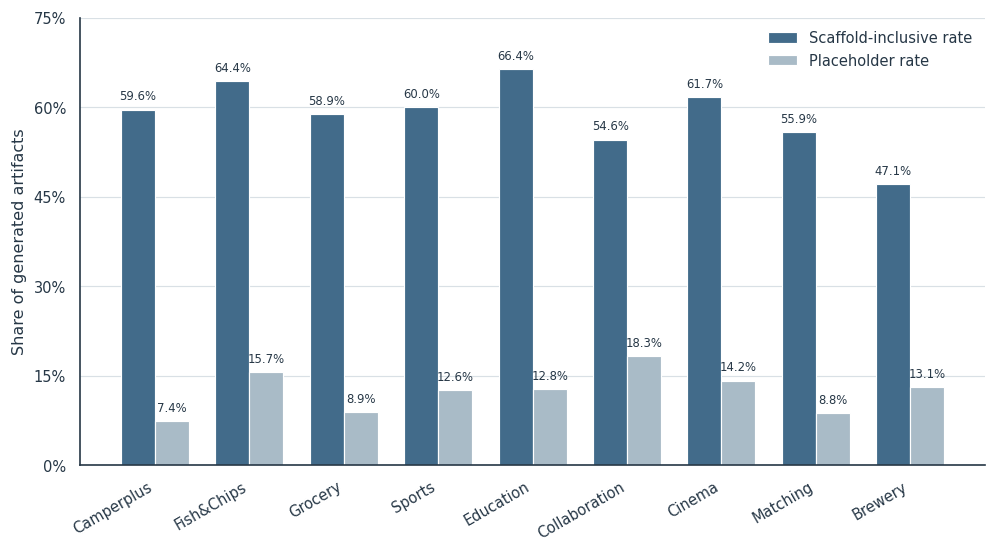

In [19]:
fig, ax = plt.subplots(figsize=(8.4, 4.7))
x_positions = np.arange(len(GENERIC_DATASET_ORDER))
bar_width = 0.36

scaffold_bars = ax.bar(
    x_positions - bar_width / 2,
    generic_rate_summary_df["scaffold_inclusive_rate"],
    width=bar_width,
    color=GENERIC_BLUE,
    edgecolor="white",
    linewidth=0.7,
    label="Scaffold-inclusive rate",
    zorder=2,
)
placeholder_bars = ax.bar(
    x_positions + bar_width / 2,
    generic_rate_summary_df["placeholder_rate"],
    width=bar_width,
    color=GENERIC_LIGHT,
    edgecolor="white",
    linewidth=0.7,
    label="Placeholder rate",
    zorder=2,
)

for bars in (scaffold_bars, placeholder_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1.1,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=7,
            color=GENERIC_DARK,
        )

ax.set_ylabel("Share of generated artifacts")
ax.set_xlabel("")
ax.set_ylim(0, 75)
ax.set_yticks(np.arange(0, 76, 15))
ax.set_yticklabels([f"{value}%" for value in range(0, 76, 15)])
ax.set_xticks(x_positions)
ax.set_xticklabels(
    [GENERIC_DATASET_LABELS[name] for name in GENERIC_DATASET_ORDER],
    rotation=30,
    ha="right",
)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
generic_export_figure(fig, "generic_artifact_rates")
plt.show()